# Análise de Avaliação — FaceGroundVLM / TinyLLaVA

Notebook reutilizável para inspecionar o resultado de qualquer rodada de\n`evaluation/evaluate.py`. Basta apontar `RUN_DIR` para a pasta do\nexperimento (a que contém `evaluation/results.json` e\n`evaluation/predictions.jsonl`) e rodar todas as células.

**Conteúdo**

1. Carregamento das métricas e predições por amostra.
2. Tabela resumo (parser estrito vs. legacy).
3. Matrizes de confusão lado a lado.
4. Acurácia / recall(fake) por método de manipulação (DD-VQA).
5. Distribuição das métricas de geração (BLEU/ROUGE/CIDEr).
6. Análise de coerência: o veredito bate com a justificativa?
7. Galeria de exemplos filtráveis com imagem, pergunta, geração e referência.

**Dependências:** `pandas`, `matplotlib`, `Pillow`. Opcional: `seaborn`.

```bash
pip install pandas matplotlib pillow seaborn
```

## 1. Configuração

Edite os caminhos abaixo para apontar para a rodada que você quer
analisar. Tudo o resto roda em cascata.

In [8]:
from pathlib import Path

# === EDITAR AQUI =============================================================
# Pasta da rodada (output_dir do config). Pode ser relativa ao notebook ou
# absoluta. Comente/descomente as linhas para alternar entre rodadas.
RUN_DIR = Path("../outputs/tinyllava_stage2_finetune_rund")
# RUN_DIR = Path("../outputs/tinyllava_stage2_finetune_runc")

# Onde estão as imagens originais do split avaliado. Se vazio ou inexistente,
# a galeria de exemplos exibe só o texto. Útil quando você só faz rsync dos
# JSONs e mantém as imagens no servidor remoto.
IMAGE_ROOT = Path("/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigLlama/ddvqa/frames")

# Quantos exemplos exibir em cada categoria da galeria (acerto/erro x real/fake).
GALLERY_PER_BUCKET = 4

# Tamanho da figura padrão (largura, altura) em polegadas.
FIGSIZE = (10, 6)
# =============================================================================

RESULTS_JSON = RUN_DIR / "evaluation" / "results.json"
PREDICTIONS_JSONL = RUN_DIR / "evaluation" / "predictions.jsonl"

print(f"RUN_DIR              = {RUN_DIR.resolve()}")
print(f"results.json         = {RESULTS_JSON} ({'ok' if RESULTS_JSON.exists() else 'MISSING'})")
print(f"predictions.jsonl    = {PREDICTIONS_JSONL} ({'ok' if PREDICTIONS_JSONL.exists() else 'MISSING'})")
print(f"IMAGE_ROOT           = {IMAGE_ROOT} ({'ok' if IMAGE_ROOT.exists() else 'not found - galeria sem imagens'})")


RUN_DIR              = /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigLlama/outputs/tinyllava_stage2_finetune_rund
results.json         = ../outputs/tinyllava_stage2_finetune_rund/evaluation/results.json (ok)
predictions.jsonl    = ../outputs/tinyllava_stage2_finetune_rund/evaluation/predictions.jsonl (ok)
IMAGE_ROOT           = /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigLlama/ddvqa/frames (ok)


## 2. Carregamento dos dados

In [9]:
import json

import numpy as np
import pandas as pd

with open(RESULTS_JSON) as f:
    results = json.load(f)

rows = []
with open(PREDICTIONS_JSONL) as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# Garante consistência mínima caso colunas faltem (versões antigas do
# evaluate.py podiam não escrever pred_label_legacy).
for col in ("pred_label", "pred_label_legacy", "true_label", "method"):
    if col not in df.columns:
        df[col] = None
df["correct"] = df["pred_label"] == df["true_label"]
df["correct_legacy"] = df["pred_label_legacy"] == df["true_label"]

print(f"Carregadas {len(df)} predições.")
print(f"Métodos: {sorted(df['method'].dropna().unique())}")
print(f"Distribuição true_label: {df['true_label'].value_counts().to_dict()}")
df.head(3)


Carregadas 2015 predições.
Métodos: ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'Original']
Distribuição true_label: {'fake': 1509, 'real': 506}


,image,question,reference_answer,generated,true_label,pred_label,pred_label_legacy,correct,correct_legacy,method
0,Deepfakes_116_091.jpg,Does the image looks real/fake?,Fake. The image looks fake. The person's skin ...,Fake. The image looks fake. It is an image wit...,fake,fake,fake,True,True,Deepfakes
1,Deepfakes_116_091.jpg,Does the person's skin look real/fake?,Fake. The person's skin looks fake. The person...,Fake. The person's skin looks fake. The person...,fake,fake,fake,True,True,Deepfakes
2,Deepfakes_104_126.jpg,Does the image looks real/fake?,Fake. The image looks fake. It is an image wit...,Fake. The image looks fake. It is an image wit...,fake,fake,fake,True,True,Deepfakes


## 3. Resumo das métricas

O parser **estrito** (novo) considera o primeiro veredito que aparece na
geração — é o que importa para classificação real x fake quando o modelo é
forçado a se comprometer já no primeiro token. O **legacy** dá a vitória
para qualquer ocorrência de "fake" na resposta inteira; é útil para medir
se a justificativa do modelo descreve corretamente o conteúdo, mesmo
quando o veredito explícito está errado.

In [10]:
def _fmt(x):
    if isinstance(x, float):
        return f"{x:.4f}"
    return x


detection_legacy = results.get("detection_legacy", {})

summary_rows = [
    {
        "métrica": "accuracy",
        "estrito (novo)": results.get("accuracy"),
        "legacy": detection_legacy.get("accuracy"),
    },
    {
        "métrica": "precision",
        "estrito (novo)": results.get("precision"),
        "legacy": detection_legacy.get("precision"),
    },
    {
        "métrica": "recall",
        "estrito (novo)": results.get("recall"),
        "legacy": detection_legacy.get("recall"),
    },
    {
        "métrica": "f1",
        "estrito (novo)": results.get("f1"),
        "legacy": detection_legacy.get("f1"),
    },
]
detection_df = pd.DataFrame(summary_rows).set_index("métrica")

gen_keys = ["bleu_1", "bleu_2", "bleu_3", "bleu_4",
            "rouge_1", "rouge_2", "rouge_l", "cider"]
gen_df = pd.DataFrame(
    {"valor": [results.get(k) for k in gen_keys]},
    index=gen_keys,
)

print(f"constrained_first_token = {results.get('constrained_first_token')}")
print()
print("== Detecção (real x fake) ==")
display(detection_df.style.format(_fmt))
print("== Geração textual ==")
display(gen_df.style.format(_fmt))


constrained_first_token = True

== Detecção (real x fake) ==


,estrito (novo),legacy
métrica,,
accuracy,0.6104,0.6104
precision,0.8598,0.8598
recall,0.5732,0.5732
f1,0.6879,0.6879


== Geração textual ==


,valor
bleu_1,0.2915
bleu_2,0.2570
bleu_3,0.2327
bleu_4,0.2110
rouge_1,0.5559
rouge_2,0.4465
rouge_l,0.5461
cider,2.0079


## 4. Matrizes de confusão

Esquerda: parser estrito (primeiro veredito explicitamente emitido).
Direita: parser legacy (procura "fake" em qualquer parte da resposta).
A diferença entre as duas é um indicador direto da consistência entre
veredito e justificativa.

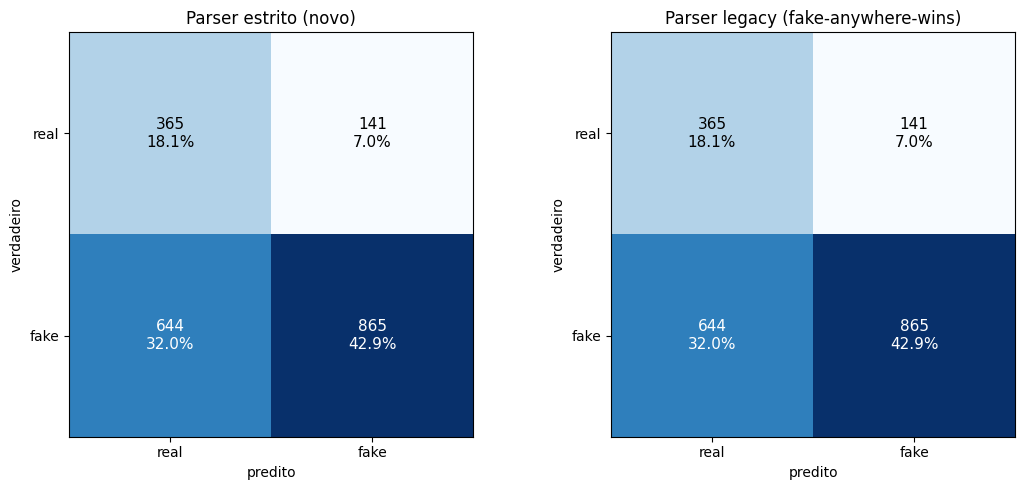

Parser estrito:


pred,real,fake
true,,
real,365,141
fake,644,865


Parser legacy:


pred,real,fake
true,,
real,365,141
fake,644,865


In [11]:
import matplotlib.pyplot as plt

LABELS = ["real", "fake"]


def confusion_matrix(df, pred_col, true_col="true_label", labels=LABELS):
    """Retorna matriz de confusão como DataFrame (linhas=true, cols=pred)."""
    cm = pd.crosstab(
        df[true_col].fillna("?"),
        df[pred_col].fillna("?"),
        rownames=["true"], colnames=["pred"],
    )
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)
    return cm


def plot_cm(ax, cm, title):
    arr = cm.values
    im = ax.imshow(arr, cmap="Blues")
    ax.set_xticks(range(len(cm.columns)), cm.columns)
    ax.set_yticks(range(len(cm.index)), cm.index)
    ax.set_xlabel("predito")
    ax.set_ylabel("verdadeiro")
    ax.set_title(title)

    total = arr.sum() or 1
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            value = arr[i, j]
            pct = value / total * 100
            color = "white" if value > arr.max() / 2 else "black"
            ax.text(
                j, i, f"{value}\n{pct:.1f}%",
                ha="center", va="center", color=color, fontsize=11,
            )
    return im


cm_new = confusion_matrix(df, "pred_label")
cm_leg = confusion_matrix(df, "pred_label_legacy")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_cm(axes[0], cm_new, "Parser estrito (novo)")
plot_cm(axes[1], cm_leg, "Parser legacy (fake-anywhere-wins)")
plt.tight_layout()
plt.show()

print("Parser estrito:")
display(cm_new)
print("Parser legacy:")
display(cm_leg)


## 5. Performance por método de manipulação

DD-VQA cobre 5 famílias de deepfake (Deepfakes, Face2Face, FaceSwap,
NeuralTextures, FaceShifter) + amostras `Original`. Quebrar a métrica
por método mostra se o modelo só aprendeu a detectar uma técnica
específica.

In [12]:
def per_method_table(df: pd.DataFrame) -> pd.DataFrame:
    """Sumário por método.

    - ``acc_strict`` / ``acc_legacy``: fração de amostras corretamente
      classificadas com o parser correspondente.
    - ``recall_fake``: TP_fake / (todas as amostras com true=fake).
    - ``spec_real``:  TN_real / (todas as amostras com true=real).
    """
    out = []
    for method, sub in df.groupby("method", dropna=False):
        n = len(sub)
        n_real = int((sub["true_label"] == "real").sum())
        n_fake = int((sub["true_label"] == "fake").sum())

        acc_strict = sub["correct"].mean() if n else float("nan")
        acc_legacy = sub["correct_legacy"].mean() if n else float("nan")

        recall_fake = (
            ((sub["true_label"] == "fake") & (sub["pred_label"] == "fake")).sum()
            / max(n_fake, 1)
        )
        spec_real = (
            ((sub["true_label"] == "real") & (sub["pred_label"] == "real")).sum()
            / max(n_real, 1)
        )
        recall_fake_legacy = (
            ((sub["true_label"] == "fake") & (sub["pred_label_legacy"] == "fake")).sum()
            / max(n_fake, 1)
        )

        out.append({
            "method": method,
            "n": n,
            "n_real": n_real,
            "n_fake": n_fake,
            "acc_strict": acc_strict,
            "acc_legacy": acc_legacy,
            "recall_fake_strict": recall_fake,
            "recall_fake_legacy": recall_fake_legacy,
            "spec_real_strict": spec_real,
        })
    return pd.DataFrame(out).sort_values("method").reset_index(drop=True)


method_df = per_method_table(df)
display(
    method_df.style
    .format({
        "acc_strict": _fmt, "acc_legacy": _fmt,
        "recall_fake_strict": _fmt, "recall_fake_legacy": _fmt,
        "spec_real_strict": _fmt,
    })
    .background_gradient(
        subset=["acc_strict", "recall_fake_strict", "spec_real_strict"],
        cmap="Blues",
    )
)


,method,n,n_real,n_fake,acc_strict,acc_legacy,recall_fake_strict,recall_fake_legacy,spec_real_strict
0,Deepfakes,416,0,416,0.7476,0.7476,0.7476,0.7476,0.0000
1,Face2Face,369,0,369,0.5149,0.5149,0.5149,0.5149,0.0000
2,FaceShifter,168,0,168,0.4702,0.4702,0.4702,0.4702,0.0000
3,FaceSwap,324,0,324,0.6543,0.6543,0.6543,0.6543,0.0000
4,NeuralTextures,232,0,232,0.3147,0.3147,0.3147,0.3147,0.0000
5,Original,506,506,0,0.7213,0.7213,0.0000,0.0000,0.7213


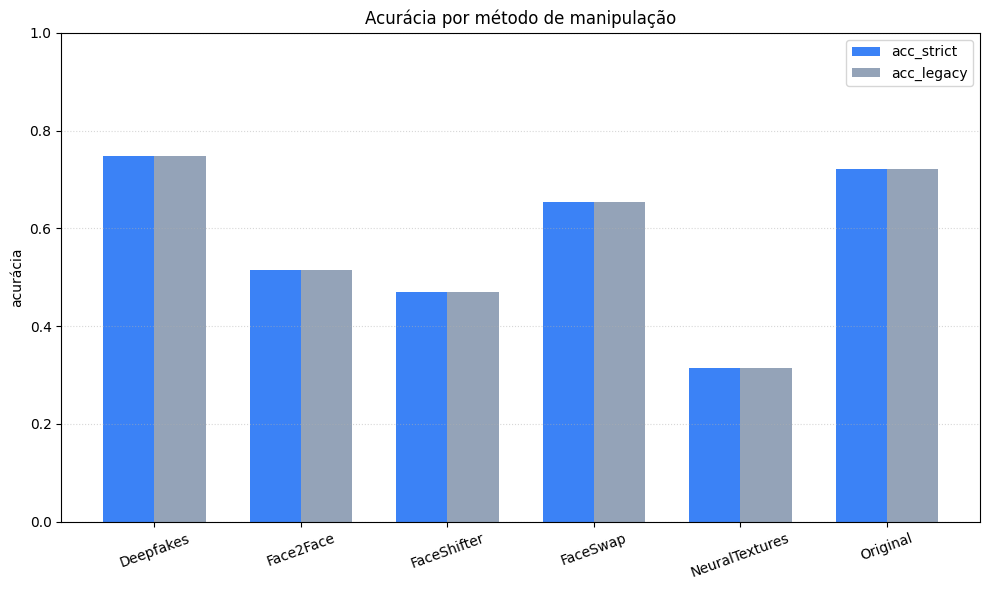

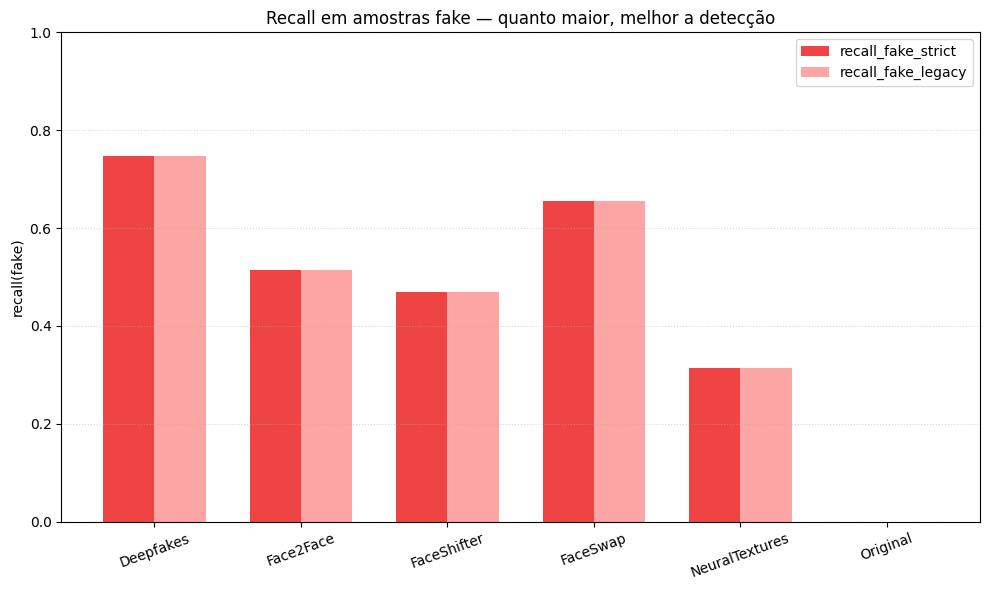

In [13]:
methods = method_df["method"].tolist()
x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(x - width / 2, method_df["acc_strict"], width,
       label="acc_strict", color="#3b82f6")
ax.bar(x + width / 2, method_df["acc_legacy"], width,
       label="acc_legacy", color="#94a3b8")
ax.set_xticks(x, methods, rotation=20)
ax.set_ylim(0, 1)
ax.set_ylabel("acurácia")
ax.set_title("Acurácia por método de manipulação")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(x - width / 2, method_df["recall_fake_strict"], width,
       label="recall_fake_strict", color="#ef4444")
ax.bar(x + width / 2, method_df["recall_fake_legacy"], width,
       label="recall_fake_legacy", color="#fca5a5")
ax.set_xticks(x, methods, rotation=20)
ax.set_ylim(0, 1)
ax.set_ylabel("recall(fake)")
ax.set_title("Recall em amostras fake — quanto maior, melhor a detecção")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


## 6. Métricas de geração textual

BLEU-1..4, ROUGE-1/2/L e CIDEr medem o quão parecida a justificativa
gerada é com a resposta de referência. Não dizem nada sobre o veredito
em si.

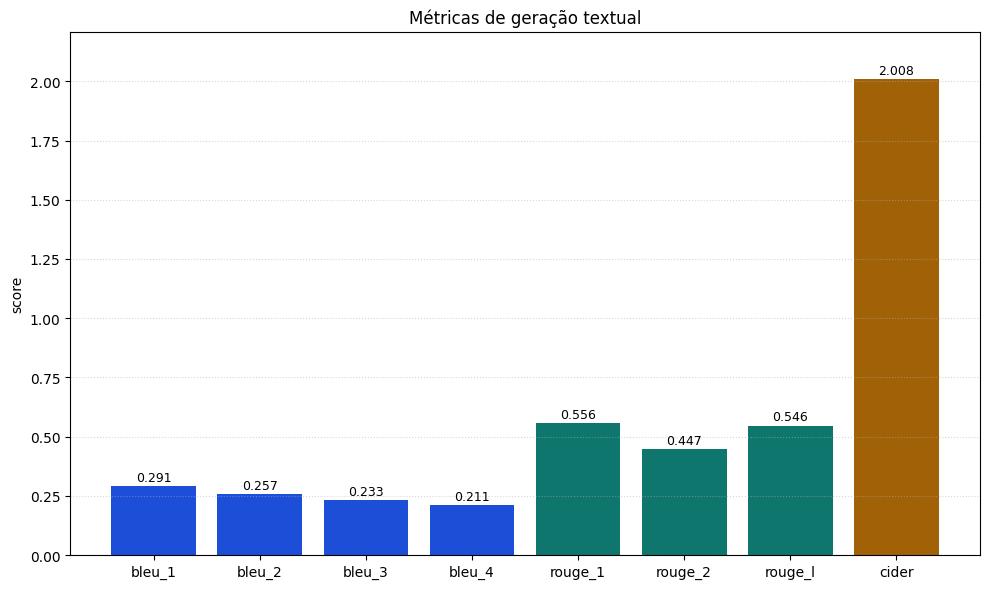

In [14]:
gen_values = [results.get(k, 0.0) or 0.0 for k in gen_keys]

fig, ax = plt.subplots(figsize=FIGSIZE)
colors = ["#1d4ed8"] * 4 + ["#0f766e"] * 3 + ["#a16207"]
bars = ax.bar(gen_keys, gen_values, color=colors)
ax.set_ylim(0, max(1.0, max(gen_values) * 1.1))
ax.set_ylabel("score")
ax.set_title("Métricas de geração textual")
ax.grid(axis="y", linestyle=":", alpha=0.5)
for bar, value in zip(bars, gen_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center", va="bottom", fontsize=9,
    )
plt.tight_layout()
plt.show()


## 7. Coerência entre veredito e justificativa

Cruza o veredito do parser estrito com o do parser legacy. Quatro
quadrantes:

- ambos certos → o modelo se compromete com o veredito correto **e** a
  descrição corrobora;
- só legacy certo → o modelo descreve corretamente o defeito, mas o
  primeiro token (veredito) saiu errado — sintoma clássico do bug de
  off-by-one nos labels;
- só estrito certo → veredito correto sem que a descrição mencione o
  outro lado (raro);
- ambos errados → erro completo.

Distribuição global:


,n,%
coerencia,,
ambos_certos,1230,61.04
só_legacy_certo,0,0.00
só_estrito_certo,0,0.00
ambos_errados,785,38.96


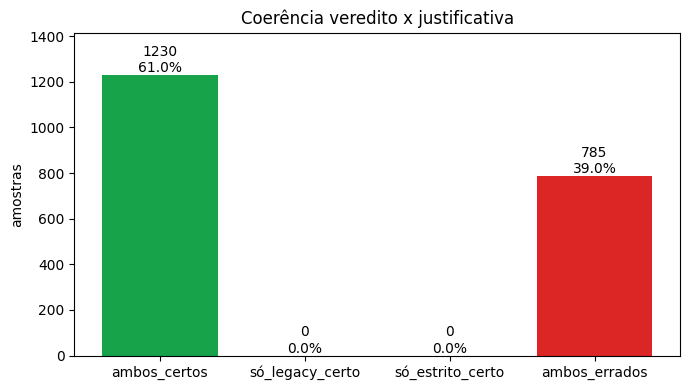


Quebra por verdadeiro rótulo:


coerencia,ambos_certos,ambos_errados
true_label,,
fake,0.573,0.427
real,0.721,0.279


In [15]:
def coherence_bucket(row):
    s = bool(row["correct"])
    l = bool(row["correct_legacy"])
    if s and l:
        return "ambos_certos"
    if s and not l:
        return "só_estrito_certo"
    if not s and l:
        return "só_legacy_certo"
    return "ambos_errados"


df["coerencia"] = df.apply(coherence_bucket, axis=1)

coherence_counts = df["coerencia"].value_counts().reindex([
    "ambos_certos", "só_legacy_certo", "só_estrito_certo", "ambos_errados",
], fill_value=0)
coherence_pct = coherence_counts / max(len(df), 1)

print("Distribuição global:")
display(
    pd.DataFrame({
        "n": coherence_counts,
        "%": (coherence_pct * 100).round(2),
    })
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coherence_counts.index, coherence_counts.values,
       color=["#16a34a", "#f59e0b", "#0ea5e9", "#dc2626"])
for i, v in enumerate(coherence_counts.values):
    ax.text(i, v, f"{v}\n{coherence_pct.iloc[i]*100:.1f}%",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("amostras")
ax.set_title("Coerência veredito x justificativa")
ax.set_ylim(0, coherence_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("\nQuebra por verdadeiro rótulo:")
display(
    pd.crosstab(df["true_label"], df["coerencia"], normalize="index")
    .round(3)
)


## 8. Galeria de exemplos

Exibe `GALLERY_PER_BUCKET` exemplos de cada combinação
`(true_label, correto?)`. Use os filtros (`method`, `parser`) para
investigar casos específicos.

Se as imagens não estiverem disponíveis localmente
(`IMAGE_ROOT` não existe), só o texto é exibido.

In [16]:
from IPython.display import HTML, display
from PIL import Image

_HAS_IMAGES = IMAGE_ROOT.exists()


def _resolve_image(rel_path: str) -> Path | None:
    if not rel_path or not _HAS_IMAGES:
        return None
    p = IMAGE_ROOT / rel_path
    return p if p.is_file() else None


def _truncate(text: str, n: int = 380) -> str:
    text = (text or "").strip().replace("\n", " ")
    return text if len(text) <= n else text[: n - 1] + "…"


def show_examples(
    sample_df: pd.DataFrame,
    title: str,
    n: int = GALLERY_PER_BUCKET,
    parser: str = "strict",
    seed: int = 0,
) -> None:
    if sample_df.empty:
        print(f"[{title}] sem amostras.")
        return

    pick = sample_df.sample(n=min(n, len(sample_df)), random_state=seed)
    pred_col = "pred_label" if parser == "strict" else "pred_label_legacy"

    print(f"\n=== {title}  (n={len(sample_df)}, exibindo {len(pick)}) ===")
    cols = max(1, min(n, len(pick)))
    fig_height = 3.2 if _HAS_IMAGES else 0.1
    fig, axes = plt.subplots(1, cols, figsize=(3.2 * cols, fig_height))
    if cols == 1:
        axes = [axes]

    captions = []
    for ax, (_, row) in zip(axes, pick.iterrows()):
        ax.axis("off")
        img_path = _resolve_image(row["image"])
        if img_path is not None:
            try:
                ax.imshow(Image.open(img_path).convert("RGB"))
            except Exception as e:
                ax.text(0.5, 0.5, f"erro: {e}", ha="center", va="center")
        else:
            ax.text(0.5, 0.5, row["image"], ha="center", va="center", fontsize=8)

        ax.set_title(
            f"{row['method']}  ·  true={row['true_label']}  ·  pred={row[pred_col]}",
            fontsize=9,
        )
        captions.append({
            "image": row["image"],
            "method": row["method"],
            "true": row["true_label"],
            "pred_strict": row["pred_label"],
            "pred_legacy": row["pred_label_legacy"],
            "question": row["question"],
            "generated": _truncate(row["generated"]),
            "reference": _truncate(row["reference_answer"]),
        })

    if _HAS_IMAGES:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)

    rows_html = []
    for c in captions:
        rows_html.append(
            "<tr>"
            f"<td><b>{c['image']}</b><br><small>{c['method']}</small></td>"
            f"<td><span style='color:#1d4ed8'><b>true:</b> {c['true']}</span><br>"
            f"<span style='color:#16a34a'><b>pred_strict:</b> {c['pred_strict']}</span><br>"
            f"<span style='color:#94a3b8'><b>pred_legacy:</b> {c['pred_legacy']}</span></td>"
            f"<td><b>Q:</b> {c['question']}<br>"
            f"<b>Gen:</b> {c['generated']}<br>"
            f"<b>Ref:</b> {c['reference']}</td>"
            "</tr>"
        )
    table = (
        "<table style='font-size:11px;border-collapse:collapse;width:100%'>"
        "<thead><tr>"
        "<th style='text-align:left;width:18%'>imagem</th>"
        "<th style='text-align:left;width:18%'>labels</th>"
        "<th style='text-align:left'>texto</th>"
        "</tr></thead><tbody>" + "".join(rows_html) + "</tbody></table>"
    )
    display(HTML(table))


def filter_df(method: str | None = None) -> pd.DataFrame:
    sub = df
    if method is not None:
        sub = sub[sub["method"] == method]
    return sub



=== FAKE corretamente detectado  (n=865, exibindo 4) ===


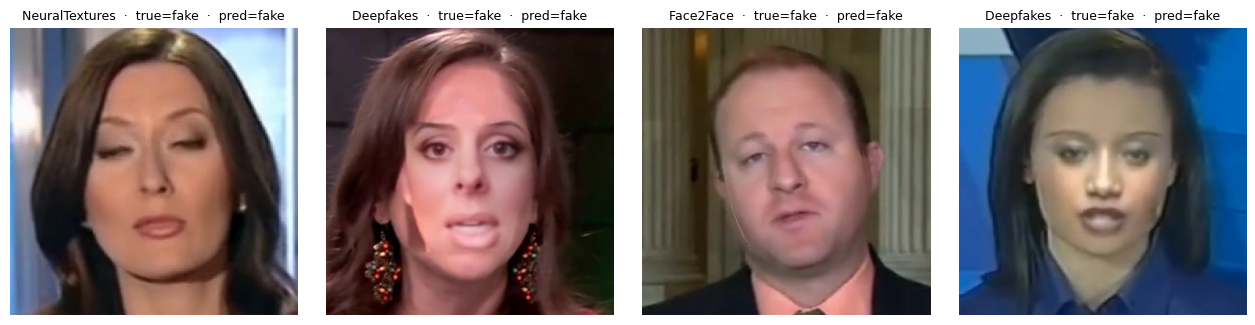

imagem,labels,texto
NeuralTextures_956_958.jpgNeuralTextures,true: fakepred_strict: fakepred_legacy: fake,Q: Does the person's nose look real/fake?Gen: Fake. The person's nose looks fake. The person has mismatched nose.Ref: Fake. The person's nose looks fake. The person's nose looks a bit fake because the nose lookes curved.
Deepfakes_402_453.jpgDeepfakes,true: fakepred_strict: fakepred_legacy: fake,Q: Does the person's nose look real/fake?Gen: Fake. The person's nose looks fake. The person has naturally thin nose.Ref: Fake. The person's nose looks fake. The person's nose looks very fake because the nose is placed at the wrong place on the face.
Face2Face_557_560.jpgFace2Face,true: fakepred_strict: fakepred_legacy: fake,Q: Do the person's eyes look real/fake?Gen: Fake. The person's eyes look fake. The person has double eyes looks a bit fake because the eyes appear overly small to the face.Ref: Fake. The person's eyes look fake. The person's eyes look very fake because the eyes look unnaturally asymmetric.
Deepfakes_316_369.jpgDeepfakes,true: fakepred_strict: fakepred_legacy: fake,Q: Does the person's mouth look real/fake?Gen: Fake. The person's mouth looks fake. The person has misplaced teeth.Ref: Fake. The person's mouth looks fake. The person's mouth looks very fake because the teeth look unnatural coloring.



=== FAKE não detectado (falso negativo)  (n=644, exibindo 4) ===


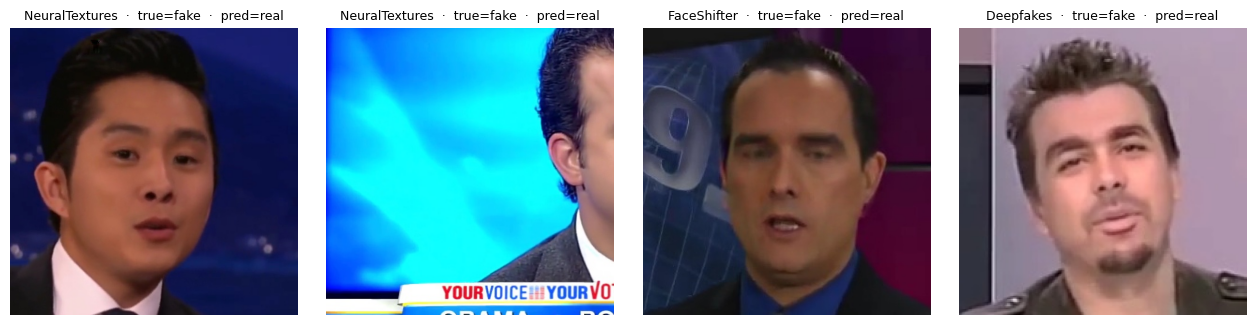

imagem,labels,texto
NeuralTextures_971_564.jpgNeuralTextures,true: fakepred_strict: realpred_legacy: real,Q: Does the person's mouth look real/fake?Gen: Real. The person's mouth looks real. The person has naturally full mouth.Ref: Fake. The person's mouth looks fake. The person's mouth looks a bit fake because the mouth is misaligned with other facial features.
NeuralTextures_640_638.jpgNeuralTextures,true: fakepred_strict: realpred_legacy: real,Q: Do the person's eyebrows look real/fake?Gen: Real. The person's eyebrows look real. The person has naturally arched eyebrow.Ref: Fake. The person's eyebrows look fake. The person's eyebrows look a bit fake because left broken eyebrows.
FaceShifter_622_647.jpgFaceShifter,true: fakepred_strict: realpred_legacy: real,Q: Does the person's mouth look real/fake?Gen: Real. The person's mouth looks real. The person has naturally full mouth.Ref: Fake. The person's mouth looks fake. The person's mouth looks a bit fake because the mouth looks too rigid to convey expressions.
Deepfakes_175_159.jpgDeepfakes,true: fakepred_strict: realpred_legacy: real,Q: Does the person's mouth look real/fake?Gen: Real. The person's mouth looks real. The person has naturally full mouth.Ref: Fake. The person's mouth looks fake. The person's mouth looks very fake because the mouth is misaligned with other facial features.



=== REAL corretamente classificado  (n=365, exibindo 4) ===


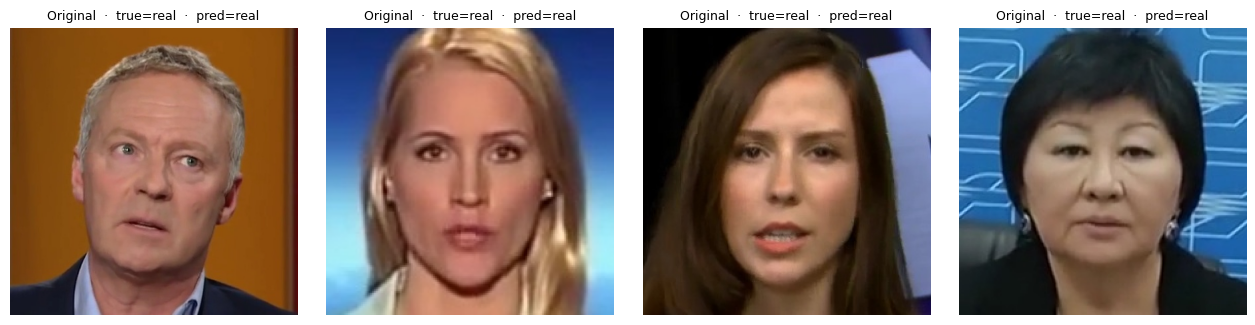

imagem,labels,texto
Original_273.jpgOriginal,true: realpred_strict: realpred_legacy: real,Q: Does the person's nose look real/fake?Gen: Real. The person's nose looks real. The person has naturally straight nose.Ref: Real. The person's nose looks real. The person has naturally pointed nose.
Original_606.jpgOriginal,true: realpred_strict: realpred_legacy: real,Q: Does the person's nose look real/fake?Gen: Real. The person's nose looks real. The person has naturally straight nose.Ref: Real. The person's nose looks real. The person has naturally straight nose.
Original_951.jpgOriginal,true: realpred_strict: realpred_legacy: real,Q: Does the person's skin look real/fake?Gen: Real. The person's skin looks real. The person has naturally smooth illuminated skin.Ref: Real. The person's skin looks real. The person has naturally smooth even skin.
Original_455.jpgOriginal,true: realpred_strict: realpred_legacy: real,"Q: Does the image looks real/fake?Gen: Real. The image looks real. Proper hair and hairstyles. The person has smooth skin, arched eyebrows, round eyes, straight nose, full mouth.Ref: Real. The image looks real. Proper hair and hairstyles. The person has smooth skin, straight eyebrows, deep eyes, broad nose, full mouth."



=== REAL classificado como fake (falso positivo)  (n=141, exibindo 4) ===


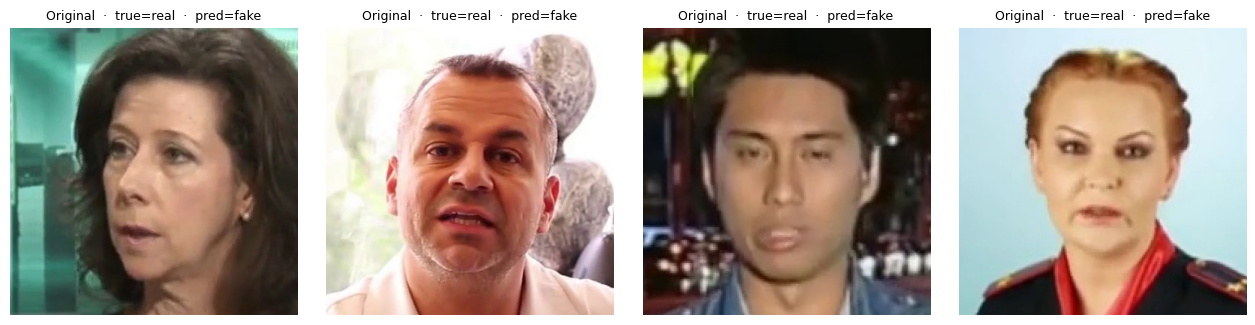

imagem,labels,texto
Original_299.jpgOriginal,true: realpred_strict: fakepred_legacy: fake,Q: Do the person's eyebrows look real/fake?Gen: Fake. The person's eyebrows look fake. The person has blurry overlapped eyebrow.Ref: Real. The person's eyebrows look real. The person has naturally arched eyebrows.
Original_416.jpgOriginal,true: realpred_strict: fakepred_legacy: fake,Q: Does the person's skin look real/fake?Gen: Fake. The person's skin looks fake. The person has an ill-fitted skin.Ref: Real. The person's skin looks real. The person has naturally smooth skin.
Original_023.jpgOriginal,true: realpred_strict: fakepred_legacy: fake,"Q: Does the image looks real/fake?Gen: Fake. The image looks fake. It is an image with manipulated face regions. The person's eyes look a bit fake because the eyes are placed at the wrong place on the face. The person has mismatched bangs.Ref: Real. The image looks real. The person have complete face feature. Those features are in good shape, size, and positioning. The person has wrinked skin, thick eyebrows, large eyes, pointed nose, pouty mouth."
Original_472.jpgOriginal,true: realpred_strict: fakepred_legacy: fake,"Q: Does the image looks real/fake?Gen: Fake. The image looks fake. It is an image with manipulated face regions. The person's skin looks very fake because the skin is overly smooth and lacks of details, such as skin texture there are stains/flaws on the person's face there are areas looking unnaturally brighter there area of looking unnatured there area of lookin g fakeRef: Real. The image looks real. The person exhibit natural skin textures. The person has smooth skin, arched eyebrows, round eyes, straight nose, full mouth."


In [17]:
# === Filtros opcionais para a galeria ========================================
GALLERY_METHOD = None  # ex: "Deepfakes", "Original" (None = todos)
GALLERY_PARSER = "strict"  # "strict" ou "legacy"
# =============================================================================

base = filter_df(method=GALLERY_METHOD)

show_examples(
    base[(base["true_label"] == "fake") & base["correct"]],
    title="FAKE corretamente detectado",
    parser=GALLERY_PARSER,
)
show_examples(
    base[(base["true_label"] == "fake") & ~base["correct"]],
    title="FAKE não detectado (falso negativo)",
    parser=GALLERY_PARSER,
)
show_examples(
    base[(base["true_label"] == "real") & base["correct"]],
    title="REAL corretamente classificado",
    parser=GALLERY_PARSER,
)
show_examples(
    base[(base["true_label"] == "real") & ~base["correct"]],
    title="REAL classificado como fake (falso positivo)",
    parser=GALLERY_PARSER,
)


### Casos onde estrito e legacy discordam

Útil para inspecionar o famoso "Real. ... looks fake ..." — quando o
modelo descreve corretamente os artefatos mas tropeça no veredito (ou
vice-versa). Esse balde sempre era zero antes do fix de tokenização e
tende a diminuir conforme o modelo aprende a se comprometer no primeiro
token.

In [19]:
disagree = df[df["pred_label"] != df["pred_label_legacy"]]

print(f"Amostras com discordância estrito x legacy: {len(disagree)} / {len(df)}")
if len(disagree):
    show_examples(
        disagree,
        title="Discordância estrito x legacy",
        n=GALLERY_PER_BUCKET * 2,
    )


Amostras com discordância estrito x legacy: 0 / 2015


## 9. Exporta resumo consolidado (opcional)

Salva um CSV com a tabela por método e o resumo de coerência ao lado de
`results.json`. Útil para anexar em diários de experimento.

In [12]:
summary_path = RUN_DIR / "evaluation" / "per_method_summary.csv"
method_df.to_csv(summary_path, index=False)

coherence_path = RUN_DIR / "evaluation" / "coherence_summary.csv"
pd.DataFrame({
    "n": coherence_counts,
    "pct": (coherence_pct * 100).round(2),
}).to_csv(coherence_path)

print(f"Resumos salvos em:\n  {summary_path}\n  {coherence_path}")


Resumos salvos em:
  ../outputs/tinyllava_stage2_finetune_runc/evaluation/per_method_summary.csv
  ../outputs/tinyllava_stage2_finetune_runc/evaluation/coherence_summary.csv
